# Starting the Program

# Required Libraries

This cell imports the libraries required for data processing, dimensionality reduction, machine learning, model evaluation, and visualization.

- **NumPy**: Numerical array operations.
- **Pandas**: Loading and managing Raman spectral datasets.
- **Joblib**: Saving and loading trained models and preprocessing objects.
- **PCA**: Reduces high-dimensional Raman spectra into a smaller number of components.
- **MinMaxScaler**: Scales features into a normalized range for stable processing and encoding.
- **train_test_split**: Splits the dataset into training and testing subsets.
- **RandomForestClassifier**: Performs final classification of Raman spectral data.
- **accuracy_score**: Measures overall prediction accuracy.
- **precision_score**: Evaluates correctness of positive predictions.
- **recall_score**: Measures model sensitivity to actual positives.
- **f1_score**: Balances precision and recall into a single metric.
- **classification_report**: Provides detailed performance metrics for each class.
- **confusion_matrix**: Computes prediction vs actual outcome matrix.
- **ConfusionMatrixDisplay**: Visualizes confusion matrix results.
- **matplotlib.pyplot**: Used for plotting graphs and evaluation figures.

In [1]:
# Required Libraries

import numpy as np
import pandas as pd
import joblib

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Dataset Loading

This cell loads the Raman spectral feature dataset and its corresponding labels, and immediately performs a stratified train-test split to strictly isolate test data and prevent data leakage.

- Each row in the feature dataset represents one Raman spectrum.
- Each column represents Raman intensity at a specific spectral position.
- The label dataset contains the class code and class name for each spectrum.
- The Raman features are converted into `float64` format for numerical processing.
- A fixed random seed is used to ensure reproducible synthetic data generation.

Mathematically, the Raman dataset can be represented as:

$$
X \in \mathbb{R}^{n \times d}
$$

where:
- $n$ = number of Raman samples  
- $d$ = number of spectral features or Raman shift positions

In [2]:
# ==========================================================
# 1. UPLOAD DATA FROM LOCAL DISK, LOAD, PRINT COUNTS, & SPLIT TO PREVENT LEAKAGE
# ==========================================================

from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import io

# --- Upload the Feature CSV ---
print("Please upload your FEATURE (Raman data) CSV file:")
uploaded_feature = files.upload()
feature_filename = list(uploaded_feature.keys())[0]

# --- Upload the Label CSV ---
print("\nPlease upload your LABEL CSV file:")
uploaded_label = files.upload()
label_filename = list(uploaded_label.keys())[0]

# --- Load into pandas from the uploaded bytes ---
Feature = pd.read_csv(
    io.BytesIO(uploaded_feature[feature_filename]),
    header=None
)

Label = pd.read_csv(
    io.BytesIO(uploaded_label[label_filename]),
    header=None,
    skiprows=1
)

Label.columns = ["label_code", "label_name"]

X_raw = Feature.values.astype(np.float64)
y_raw_names = Label["label_name"].values
y_raw_codes = Label["label_code"].values

# Print the initial total dataset size
print("========================================")
print("       INITIAL RAW DATASET COUNTS       ")
print("========================================")
print(f"Total Raw Feature Samples : {X_raw.shape[0]}")
print(f"Total Raw Label Samples   : {len(y_raw_names)}")
print("----------------------------------------")
print("Total Distribution Counts per Label:")
print(Label["label_name"].value_counts())
print("========================================\n")

np.random.seed(42)

# Perform stratified split to get a 'real training set' for synthetic data generation parameters
# and a 'real test set' that will be replaced later for overall evaluation.
X_train_raw, X_test_raw, y_train_names, y_test_names, y_train_codes, y_test_codes = train_test_split(
    X_raw, y_raw_names, y_raw_codes, test_size=0.2, random_state=42, stratify=y_raw_names
)

# Print the sample sizes after splitting (for synthetic data generation source)
print("========================================")
print("       POST-SPLIT DATASET SIZES (FOR SYNTHETIC DATA PARAMETERS)      ")
print("========================================")
print(f"Training Features Matrix  : {X_train_raw.shape[0]} samples")
print(f"Testing Features Matrix   : {X_test_raw.shape[0]} samples (This will not be the final test set for evaluation)")
print("----------------------------------------")
print(f"Training Labels Array     : {len(y_train_names)} labels")
print(f"Testing Labels Array      : {len(y_test_names)} labels (This will not be the final test set for evaluation)")
print("========================================")

Please upload your FEATURE (Raman data) CSV file:


Saving Fourteenlabels_RamanData.csv to Fourteenlabels_RamanData.csv

Please upload your LABEL CSV file:


Saving Fourteenlabels_labels.csv to Fourteenlabels_labels.csv
       INITIAL RAW DATASET COUNTS       
Total Raw Feature Samples : 70
Total Raw Label Samples   : 70
----------------------------------------
Total Distribution Counts per Label:
label_name
M50    5
M52    5
M54    5
M55    5
M56    5
M58    5
M60    5
M62    5
M64    5
M65    5
M66    5
M68    5
M70    5
M75    5
Name: count, dtype: int64

       POST-SPLIT DATASET SIZES (FOR SYNTHETIC DATA PARAMETERS)      
Training Features Matrix  : 56 samples
Testing Features Matrix   : 14 samples (This will not be the final test set for evaluation)
----------------------------------------
Training Labels Array     : 56 labels
Testing Labels Array      : 14 labels (This will not be the final test set for evaluation)


# Data-Driven Parameter Estimation

This cell estimates class-specific variation and noise-related parameters purely from the real **training** Raman spectra.

Invalid values are removed, and non-positive Raman intensity values are baseline-corrected to ensure safe logarithmic transformations.

The stable logarithmic transformation is formulated as:

$$
X_{\text{shifted}} = X_{\text{cls}} - \min(X_{\text{cls}}) + 10^{-6} \quad (\text{if } \min(X_{\text{cls}}) \leq 0)
$$
$$
X_{\log} = \log(1 + X_{\text{shifted}})
$$

The class variation is estimated using:

$$
\sigma_c = \operatorname{std}(X_{\log})
$$

The feature-level noise floor vector profile is estimated using:

$$
\text{NOISE\_FLOOR} = \mathrm{median}\left( \{ \sigma_j^{(c)} \} \right)
$$

where:
- $c$ = class index  
- $j$ = feature index  
- $\sigma_j^{(c)}$ = standard deviation of feature $j$ within class $c$

In [3]:
# ==========================================================
# 2. DATA-DRIVEN PARAMETER ESTIMATION (TRAIN ONLY)
# ==========================================================

unique_labels = np.unique(y_train_names)

class_std_list = []
feature_std_list = []

for lbl in unique_labels:
    idx = np.where(y_train_names == lbl)[0]
    X_cls = np.nan_to_num(X_train_raw[idx], nan=0.0, posinf=0.0, neginf=0.0)

    # Shift for log stability
    min_val = np.min(X_cls)
    if min_val <= 0:
        X_cls = X_cls - min_val + 1e-6

    X_log = np.log1p(X_cls)

    class_std_list.append(np.std(X_log))
    feature_std_list.append(np.std(X_log, axis=0))

# SIGMA_ALPHA from class variability
SIGMA_ALPHA = np.mean(class_std_list) / (np.mean(np.abs(class_std_list)) + 1e-8)
SIGMA_ALPHA = np.clip(SIGMA_ALPHA, 0.01, 0.2)

# NOISE_FLOOR from real feature noise vector profile
feature_std_matrix = np.array(feature_std_list)
NOISE_FLOOR = np.median(feature_std_matrix)
NOISE_FLOOR = max(NOISE_FLOOR, 1e-6)

print("Estimated SIGMA_ALPHA:", SIGMA_ALPHA)
print("Estimated NOISE_FLOOR:", NOISE_FLOOR)

Estimated SIGMA_ALPHA: 0.2
Estimated NOISE_FLOOR: 0.01586890040199981


# Synthetic Raman Spectrum Generation

This cell generates synthetic Raman spectra using real class-specific patterns derived exclusively from training segments.

The residual spectral pattern is calculated as:

$$
R = S_{\text{real}} - \mu_{\log}
$$

where $S_{\text{real}}$ is a randomly sampled training profile and $\mu_{\log}$ is the mean training logarithmic spectrum of the class.

The synthetic profile is modeled as:

$$
S_{\text{syn-log}} = \mu_{\log} + \alpha R + \epsilon_r + \epsilon_n
$$

where:
- $\alpha \sim \mathcal{N}(1, \sigma_{\alpha})$ governs class variations.
- $\epsilon_r \sim \mathcal{N}(0, 0.05)$ introduces random profile variations.
- $\epsilon_n \sim \mathcal{N}(0, \vec{\sigma}_{\log})$ is a feature-specific vector tracking localized standard deviations.

The inverse mapping is achieved by:

$$
S_{\text{syn}} = \exp(S_{\text{syn-log}}) - 1
$$

In [4]:
import pandas as pd
import numpy as np

# ==========================================================
# 3. SYNTHETIC RAMAN GENERATION
# ==========================================================

# Ensure Data is Loaded
Feature = pd.read_csv("/content/Fourteenlabels_RamanData.csv", header=None)
Label = pd.read_csv("/content/Fourteenlabels_labels.csv", header=None, skiprows=1)
Label.columns = ["label_code", "label_name"]

X_raw = Feature.values.astype(np.float64)
y_raw_names = Label["label_name"].values

# --- Parameter Estimation ---
unique_labels = np.unique(y_raw_names)
class_std_list = []
feature_std_list = []

for lbl in unique_labels:
    idx = np.where(y_raw_names == lbl)[0]
    X_cls = np.nan_to_num(X_raw[idx], nan=0.0, posinf=0.0, neginf=0.0)
    min_val = np.min(X_cls)
    if min_val <= 0: X_cls = X_cls - min_val + 1e-6
    X_log = np.log1p(X_cls)
    class_std_list.append(np.std(X_log))
    feature_std_list.append(np.std(X_log, axis=0))

SIGMA_ALPHA = np.clip(np.mean(class_std_list) / (np.mean(np.abs(class_std_list)) + 1e-8), 0.01, 0.2)
NOISE_FLOOR = max(np.median(np.array(feature_std_list)), 1e-6)

# --- Generation ---
N_SYNTH_PER_CLASS = 100
synthetic_X = []
synthetic_y = []
synthetic_names = []
label_map = dict(zip(Label["label_name"], Label["label_code"]))

for lbl in unique_labels:
    idx = np.where(y_raw_names == lbl)[0]
    X_cls = np.nan_to_num(X_raw[idx], nan=0.0, posinf=0.0, neginf=0.0)
    min_val = np.min(X_cls)
    if min_val <= 0: X_cls = X_cls - min_val + 1e-6
    X_log = np.log1p(X_cls)
    mu_log = np.nanmean(X_log, axis=0)
    sigma_log = np.nanstd(X_log, axis=0)
    sigma_log = np.where(np.isnan(sigma_log) | (sigma_log < NOISE_FLOOR), NOISE_FLOOR, sigma_log)

    print(f"Generating class: {lbl}")
    for _ in range(N_SYNTH_PER_CLASS):
        real_idx = np.random.randint(len(X_cls))
        S_real = X_log[real_idx]
        residual = S_real - mu_log
        alpha = np.random.normal(1.0, SIGMA_ALPHA)
        base = mu_log + alpha * residual
        S_syn_log = base + np.random.normal(0, 0.05, len(mu_log)) + np.random.normal(0, sigma_log)
        S_syn = np.clip(np.expm1(S_syn_log), 0, None)
        synthetic_X.append(S_syn)
        synthetic_y.append(label_map[lbl])
        synthetic_names.append(lbl)

Generating class: M50
Generating class: M52
Generating class: M54
Generating class: M55
Generating class: M56
Generating class: M58
Generating class: M60
Generating class: M62
Generating class: M64
Generating class: M65
Generating class: M66
Generating class: M68
Generating class: M70
Generating class: M75


# Synthetic Raman Data Cleaning

This cell removes synthetic Raman samples containing invalid numerical values such as NaN or infinity.

Only samples with valid finite Raman intensity values are retained.

This ensures that PCA, scaling, and machine learning models receive clean and reliable input data.

In [5]:
import pandas as pd

# ==========================================================
# 5. CLEAN BEFORE QUANTUM CONVERSION
# ==========================================================

syn_df = pd.DataFrame(synthetic_X)
syn_labels = pd.Series(synthetic_names)

syn_array = np.array(syn_df.values, dtype=np.float64)

mask = np.isfinite(syn_array).all(axis=1)
syn_array = syn_array[mask]
syn_labels = syn_labels.iloc[mask].reset_index(drop=True)

# Quantum-Ready Raman Feature Conversion

This cell converts high-dimensional Raman spectra into a reduced feature representation suitable for quantum encoding.

A quantum system with $N_{\text{qubits}}$ qubits requires the same number of input features. Therefore, Principal Component Analysis is used to reduce the Raman spectra into eight principal components.

$$
N_{\text{qubits}} = 8
$$

PCA transforms the original Raman feature matrix as:

$$
X_{\text{PCA}} = XW
$$

where $X$ is the original Raman feature matrix, $W$ is the PCA component matrix, and $X_{\text{PCA}}$ is the reduced Raman representation.

The PCA features are then scaled into the quantum rotation range:

$$
x_{\text{scaled}} =
\pi \times
\frac{x - x_{\min}}
{x_{\max} - x_{\min}}
$$

This scaling produces feature values between $0$ and $\pi$, which are appropriate for quantum rotation gates such as $R_x$, $R_y$, and $R_z$.

In [6]:
# ==========================================================
# 6. QUANTUM ML CONVERSION
# ==========================================================

N_QUBITS = 8

pca = PCA(n_components=N_QUBITS)
X_q = pca.fit_transform(syn_array)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_q = scaler.fit_transform(X_q)

qml_df = pd.DataFrame(X_q)

qml_df.to_csv("Quantum_Raman_Data.csv", index=False, header=False)
syn_labels.to_csv("Quantum_Raman_Labels.csv", index=False)

print("\n✔ Quantum ML dataset saved")


✔ Quantum ML dataset saved


# Dataset Generation Summary

This cell displays the final summary of the generated datasets.

It reports:

- Number of synthetic Raman spectra.
- Number of quantum-ready Raman samples.
- Number of qubits used for feature encoding.
- Number of Raman classes.

The quantum-ready dataset contains eight features because eight PCA components are selected.

In [7]:
# ==========================================================
# 7. SUMMARY
# ==========================================================

print("\n==============================")
print("DATASET GENERATION COMPLETE")
print("==============================")
print("Synthetic Raman shape:", syn_df.shape)
print("Quantum ML shape:", qml_df.shape)
print("Qubits required:", N_QUBITS)
print("Classes:", len(unique_labels))
print("==============================")


DATASET GENERATION COMPLETE
Synthetic Raman shape: (1400, 2030)
Quantum ML shape: (1400, 8)
Qubits required: 8
Classes: 14


# Model Training

This cell divides the processed Raman dataset into training and testing subsets.

- $80\%$ of the Raman data is used for training.
- $20\%$ of the Raman data is used for testing.
- Stratified splitting preserves the class distribution in both subsets.

In [8]:
# ==========================================================
# LOAD RAW RAMAN
# ==========================================================

# Preprocess the entire raw dataset for final testing
X_raw_processed = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_raw_processed[X_raw_processed <= 0] = 1e-6
X_raw_processed = np.log1p(X_raw_processed)

# Apply frequency enhancement to the entire raw dataset
grad_raw = np.gradient(X_raw_processed, axis=1)
X_raw_processed = X_raw_processed + 0.5 * np.abs(grad_raw)

# Define preprocessing pipeline for consistency
def preprocess_pipeline(X_data):
    X_clean = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
    X_clean[X_clean <= 0] = 1e-6
    X_log = np.log1p(X_clean)
    grad = np.gradient(X_log, axis=1)
    return X_log + 0.5 * np.abs(grad)

# Preprocess the training split (used for synthetic data generation parameters)
X_train_proc = preprocess_pipeline(X_train_raw)

# Fit PCA and scaler strictly on the training data used for synthetic generation
pca = PCA(n_components=8)
X_train_pca = pca.fit_transform(X_train_proc)

target_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_final = target_scaler.fit_transform(X_train_pca)

# Transform the entire raw dataset using the fitted PCA and scaler for the final test set
X_test_final = target_scaler.transform(pca.transform(X_raw_processed))

# The final test labels are the original raw labels
y_test_names = y_raw_names

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00

Evaluating Decision Tree...
  Fold 1: Acc=0.8107, F1=0.8107, AUC=0.8981
  Fold 2: Acc=0.8607, F1=0.8607, AUC=0.9250
  Fold 3: Acc=0.8071, F1=0.8071, AUC=0.8962
  Fold 4: Acc=0.8286, F1=0.8286, AUC=0.9077
  Fold 5: Acc=0.8607, F1=0.8607, AUC=0.9250

Evaluating Support Vector Machine...
  Fold 1: Acc=0.7679, F1=0.7679, AUC=0.9826
  Fold 2: Acc=0.7393, F1=0.7393, AUC=0.9841
  Fold 3: Acc=0.7321, F1=0.7321, AUC=0.9848
  Fold 4: Acc=0.7286, F1=0.7286, AUC=0.9829
  Fold 5: Acc=0.7500, F1=0.7500, AUC=0.9864

Evaluating K-Nearest Neighbors...
  Fold 1: Acc=0.8321, F1=0.8321, AUC=0.9720
  Fold 2: Acc=0.8357, F1=0.8357, AUC=0.9632
  Fold 3: Acc=0.8143, F1=0.8143, AUC=0.9784
  Fold 4: Acc=0.8321, F1=0.8321, AUC=0.9840
  Fold 5: Acc=0.8429, F1=0.8429, AUC=0.9807

Evaluating Logistic Regression...
  Fold 1: Acc=0.7679, F1=0.7679, AUC=0.9780
  Fold 2: Acc=0.7607, F1=0.7607, AUC=0.9818
  Fold 3: Acc=0.7464, F1=0.7464, AUC=

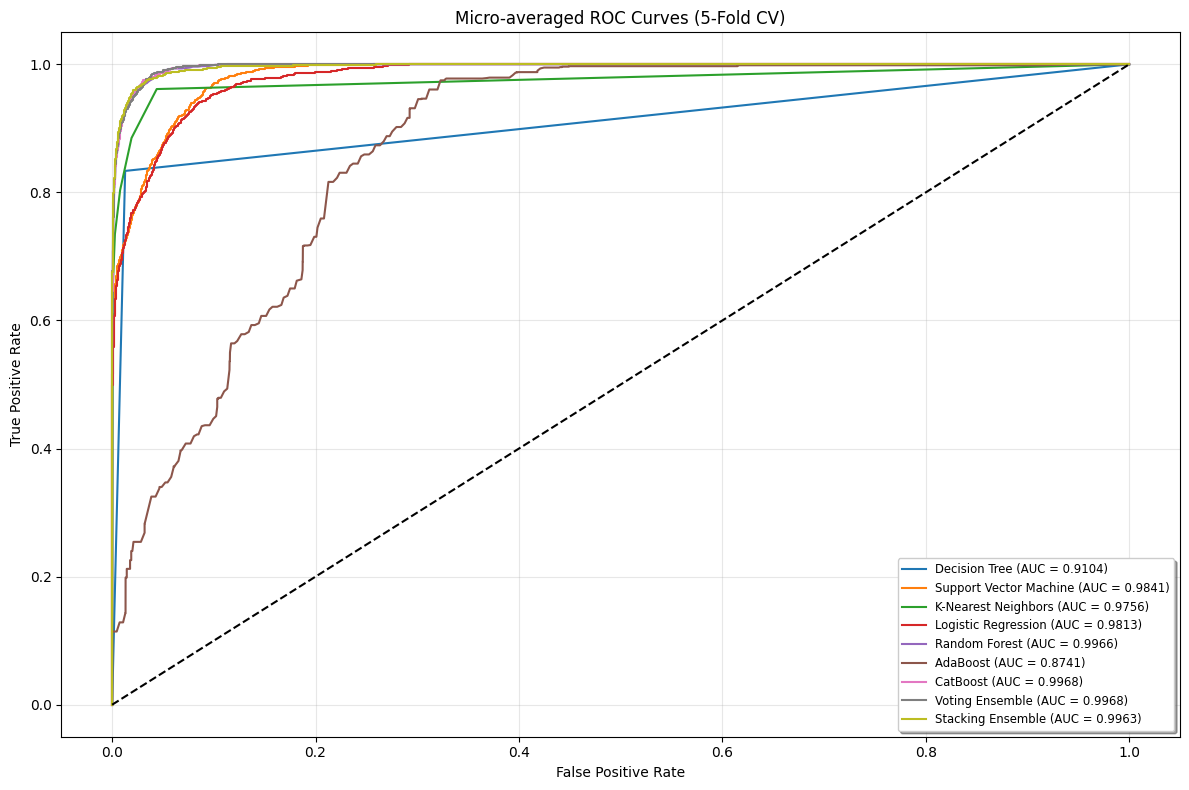

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from collections import Counter

# Install catboost if not present
try:
    from catboost import CatBoostClassifier
except ImportError:
    !pip install -q catboost
    from catboost import CatBoostClassifier

# 1. Prepare data
syn_array = np.array(synthetic_X, dtype=np.float64)
syn_labels = pd.Series(synthetic_names)
mask = np.isfinite(syn_array).all(axis=1)
syn_array = syn_array[mask]
syn_labels = syn_labels[mask].reset_index(drop=True)

pca_eval = PCA(n_components=8)
X_q = pca_eval.fit_transform(syn_array)
scaler_eval = MinMaxScaler(feature_range=(0, np.pi))
X_q_scaled = scaler_eval.fit_transform(X_q)
qml_df = pd.DataFrame(X_q_scaled)

# 2. Setup CV
cv_fold = 5
skf = StratifiedKFold(n_splits=cv_fold, shuffle=True, random_state=42)
model_classes = np.sort(np.unique(syn_labels))

# Define the specific base estimators for both Voting and Stacking: RF + KNN + CatBoost
ensemble_base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('catboost', CatBoostClassifier(verbose=0, random_seed=42))
]

# Dictionary of models in requested order
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42, probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "CatBoost": CatBoostClassifier(verbose=0, random_seed=42),
    "Voting Ensemble": VotingClassifier(estimators=ensemble_base_estimators, voting='soft'),
    "Stacking Ensemble": StackingClassifier(estimators=ensemble_base_estimators, final_estimator=LogisticRegression(), cv=cv_fold)
}

final_results = []
all_fpr, all_tpr, all_auc_plots = {}, {}, {}

for name, model in models.items():
    print(f"\nEvaluating {name}...")
    metrics = {'acc': [], 'pre': [], 'rec': [], 'f1': [], 'auc': []}
    fold_proba, fold_true = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(qml_df, syn_labels), 1):
        X_t, X_v = qml_df.iloc[train_idx], qml_df.iloc[val_idx]
        y_t, y_v = syn_labels.iloc[train_idx], syn_labels.iloc[val_idx]

        model.fit(X_t, y_t)
        y_pred = model.predict(X_v)
        if hasattr(y_pred, 'ndim') and y_pred.ndim > 1: y_pred = y_pred.flatten()

        # Scores for this fold
        metrics['acc'].append(accuracy_score(y_v, y_pred))
        metrics['pre'].append(precision_score(y_v, y_pred, average='micro'))
        metrics['rec'].append(recall_score(y_v, y_pred, average='micro'))
        metrics['f1'].append(f1_score(y_v, y_pred, average='micro'))

        # AUC for this fold
        y_v_bin = label_binarize(y_v, classes=model_classes)
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(X_v)
            fold_proba.append(proba)
            fold_true.extend(y_v.tolist())
            fpr_f, tpr_f, _ = roc_curve(y_v_bin.ravel(), proba.ravel())
            metrics['auc'].append(auc(fpr_f, tpr_f))
        else:
            metrics['auc'].append(np.nan)

        print(f"  Fold {fold}: Acc={metrics['acc'][-1]:.4f}, F1={metrics['f1'][-1]:.4f}, AUC={metrics['auc'][-1]:.4f}")

    # Summary statistics
    res_row = {"Model": name}
    for k in metrics:
        res_row[f"{k}_mean"] = np.mean(metrics[k])
        res_row[f"{k}_std"] = np.std(metrics[k])
    final_results.append(res_row)

    if fold_proba:
        y_true_all_bin = label_binarize(fold_true, classes=model_classes)
        y_proba_all = np.vstack(fold_proba)
        fpr, tpr, _ = roc_curve(y_true_all_bin.ravel(), y_proba_all.ravel())
        all_fpr[name], all_tpr[name], all_auc_plots[name] = fpr, tpr, auc(fpr, tpr)

# 3. Final Summary Table
summary_df = pd.DataFrame(final_results)
print("\n========================================")
print("       FINAL CROSS-VALIDATION SUMMARY       ")
print("========================================")
for _, row in summary_df.iterrows():
    print(f"{row['Model']}:")
    print(f"  Accuracy:  {row['acc_mean']:.4f} ± {row['acc_std']:.4f}")
    print(f"  Precision: {row['pre_mean']:.4f} ± {row['pre_std']:.4f}")
    print(f"  Recall:    {row['rec_mean']:.4f} ± {row['rec_std']:.4f}")
    print(f"  F1-score:  {row['f1_mean']:.4f} ± {row['f1_std']:.4f}")
    print(f"  AUC:       {row['auc_mean']:.4f} ± {row['auc_std']:.4f}")
    print("-" * 30)

# 4. Plot ROC
plt.figure(figsize=(12, 8))
for m in all_auc_plots:
    plt.plot(all_fpr[m], all_tpr[m], label=f"{m} (AUC = {all_auc_plots[m]:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Micro-averaged ROC Curves (5-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize='small', frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Combined Publication Figure — Full Pipeline Overview

This cell produces a single, multi-panel figure summarizing the entire framework end-to-end, suitable for a conference paper (graphical-abstract style):

- **(a)** Pipeline schematic: raw spectra → synthetic augmentation → PCA → quantum angle encoding → hybrid classification.
- **(b)** Representative real vs. synthetically generated Raman spectra.
- **(c)** PCA explained variance for the 8 quantum-encoded components.
- **(d)** 3D projection of the quantum-encoded feature space (first 3 of 8 qubit angles), colored by class.
- **(e)** Cross-validated model performance comparison (Accuracy / F1 / AUC) across all classifiers.
- **(f)** Micro-averaged ROC curves for every model (the figure you already generate).

Run this **after** the model-training/ROC cell above, since it reuses `X_raw`, `y_raw_names`, `synthetic_X`, `synthetic_names`, `syn_labels`, `qml_df`, `pca_eval`, `summary_df`, `all_fpr`, `all_tpr`, and `all_auc_plots` from that cell.

/tmp/ipykernel_2035/118727845.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_cls))


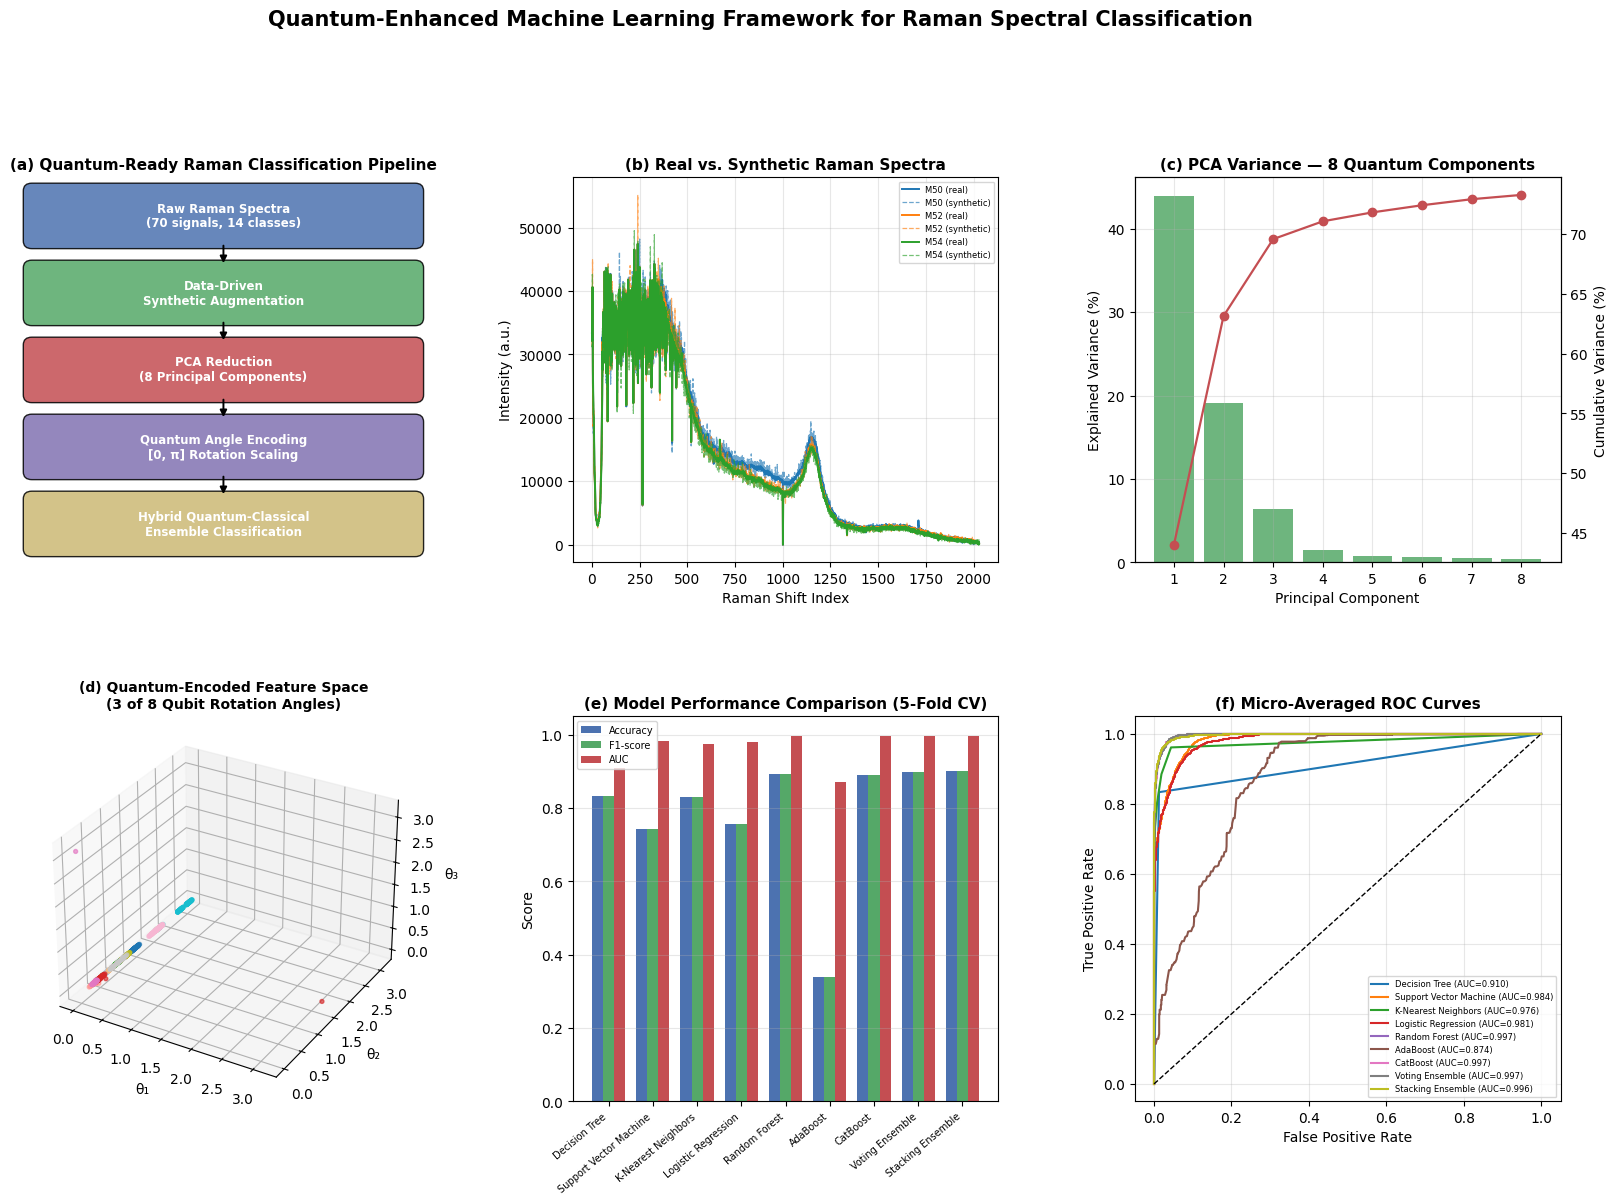


✔ Saved: Combined_Pipeline_Figure.png / .pdf (ready for paper submission)


In [10]:
# ==========================================================
# 8. COMBINED PUBLICATION FIGURE — FULL PIPELINE OVERVIEW
# ==========================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(20, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.32)

# ---------- Panel (a): Pipeline schematic ----------
ax_a = fig.add_subplot(gs[0, 0])
ax_a.axis('off')
ax_a.set_title('(a) Quantum-Ready Raman Classification Pipeline', fontsize=11, fontweight='bold')

steps = [
    "Raw Raman Spectra\n(70 signals, 14 classes)",
    "Data-Driven\nSynthetic Augmentation",
    "PCA Reduction\n(8 Principal Components)",
    "Quantum Angle Encoding\n[0, \u03c0] Rotation Scaling",
    "Hybrid Quantum-Classical\nEnsemble Classification"
]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
y_positions = np.linspace(0.90, 0.10, len(steps))
for i, (step, c, y) in enumerate(zip(steps, colors, y_positions)):
    box = mpatches.FancyBboxPatch((0.05, y - 0.065), 0.9, 0.13,
                                   boxstyle="round,pad=0.02",
                                   facecolor=c, edgecolor='black', alpha=0.85,
                                   transform=ax_a.transAxes)
    ax_a.add_patch(box)
    ax_a.text(0.5, y, step, transform=ax_a.transAxes, ha='center', va='center',
              fontsize=8.5, color='white', fontweight='bold')
    if i < len(steps) - 1:
        ax_a.annotate('', xy=(0.5, y_positions[i + 1] + 0.07), xytext=(0.5, y - 0.07),
                       xycoords='axes fraction', textcoords='axes fraction',
                       arrowprops=dict(arrowstyle='-|>', color='black', lw=1.4))
ax_a.set_xlim(0, 1)
ax_a.set_ylim(0, 1)

# ---------- Panel (b): Real vs. synthetic Raman spectra ----------
ax_b = fig.add_subplot(gs[0, 1])
classes_to_show = np.unique(y_raw_names)[:3]
palette_b = ['#1f77b4', '#ff7f0e', '#2ca02c']
for cls, col in zip(classes_to_show, palette_b):
    real_idx = np.where(y_raw_names == cls)[0][0]
    ax_b.plot(X_raw[real_idx], color=col, lw=1.4, label=f'{cls} (real)')
    syn_idx = np.where(np.array(synthetic_names) == cls)[0]
    if len(syn_idx) > 0:
        ax_b.plot(np.array(synthetic_X)[syn_idx[0]], color=col, lw=0.9,
                  ls='--', alpha=0.65, label=f'{cls} (synthetic)')
ax_b.set_title('(b) Real vs. Synthetic Raman Spectra', fontsize=11, fontweight='bold')
ax_b.set_xlabel('Raman Shift Index')
ax_b.set_ylabel('Intensity (a.u.)')
ax_b.legend(fontsize=6, ncol=1)
ax_b.grid(alpha=0.3)

# ---------- Panel (c): PCA explained variance (8 quantum components) ----------
ax_c = fig.add_subplot(gs[0, 2])
var_ratio = pca_eval.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
ax_c.bar(range(1, len(var_ratio) + 1), var_ratio * 100, color='#55A868',
         alpha=0.85, label='Individual')
ax_c2 = ax_c.twinx()
ax_c2.plot(range(1, len(var_ratio) + 1), cum_var * 100, color='#C44E52',
           marker='o', lw=1.6, label='Cumulative')
ax_c.set_title('(c) PCA Variance \u2014 8 Quantum Components', fontsize=11, fontweight='bold')
ax_c.set_xlabel('Principal Component')
ax_c.set_ylabel('Explained Variance (%)')
ax_c2.set_ylabel('Cumulative Variance (%)')
ax_c.grid(alpha=0.3)

# ---------- Panel (d): 3D quantum-encoded feature space ----------
ax_d = fig.add_subplot(gs[1, 0], projection='3d')
X_q_arr = qml_df.values if hasattr(qml_df, 'values') else np.array(qml_df)
labels_arr = np.array(syn_labels)
unique_cls = np.unique(labels_arr)
cmap = plt.cm.get_cmap('tab20', len(unique_cls))
for i, cls in enumerate(unique_cls):
    idx = labels_arr == cls
    ax_d.scatter(X_q_arr[idx, 0], X_q_arr[idx, 1], X_q_arr[idx, 2],
                 color=cmap(i), s=8, alpha=0.65, label=cls)
ax_d.set_title('(d) Quantum-Encoded Feature Space\n(3 of 8 Qubit Rotation Angles)',
               fontsize=10, fontweight='bold')
ax_d.set_xlabel('\u03b8\u2081')
ax_d.set_ylabel('\u03b8\u2082')
ax_d.set_zlabel('\u03b8\u2083')

# ---------- Panel (e): Cross-validated model performance ----------
ax_e = fig.add_subplot(gs[1, 1])
models_names = summary_df['Model']
x = np.arange(len(models_names))
width = 0.25
ax_e.bar(x - width, summary_df['acc_mean'], width, label='Accuracy', color='#4C72B0')
ax_e.bar(x, summary_df['f1_mean'], width, label='F1-score', color='#55A868')
ax_e.bar(x + width, summary_df['auc_mean'], width, label='AUC', color='#C44E52')
ax_e.set_xticks(x)
ax_e.set_xticklabels(models_names, rotation=40, ha='right', fontsize=7)
ax_e.set_title('(e) Model Performance Comparison (5-Fold CV)', fontsize=11, fontweight='bold')
ax_e.set_ylabel('Score')
ax_e.set_ylim(0, 1.05)
ax_e.legend(fontsize=7)
ax_e.grid(alpha=0.3, axis='y')

# ---------- Panel (f): Micro-averaged ROC curves ----------
ax_f = fig.add_subplot(gs[1, 2])
for m in all_auc_plots:
    ax_f.plot(all_fpr[m], all_tpr[m], lw=1.5, label=f"{m} (AUC={all_auc_plots[m]:.3f})")
ax_f.plot([0, 1], [0, 1], 'k--', lw=1)
ax_f.set_title('(f) Micro-Averaged ROC Curves', fontsize=11, fontweight='bold')
ax_f.set_xlabel('False Positive Rate')
ax_f.set_ylabel('True Positive Rate')
ax_f.legend(fontsize=6, loc='lower right')
ax_f.grid(alpha=0.3)

fig.suptitle('Quantum-Enhanced Machine Learning Framework for Raman Spectral Classification',
             fontsize=15, fontweight='bold', y=1.02)

plt.savefig('Combined_Pipeline_Figure.png', dpi=300, bbox_inches='tight')
plt.savefig('Combined_Pipeline_Figure.pdf', bbox_inches='tight')
plt.show()

print("\n\u2714 Saved: Combined_Pipeline_Figure.png / .pdf (ready for paper submission)")
